# Análise de Sentimentos em 10 Famosos Salmos

Os Salmos são textos poéticos, devocionais e espirituais que fazem parte da Bíblia. Muito utilizados para meditação, oração e louvor, eles expressam uma variedade rica de sentimentos humanos como alegria, gratidão, arrependimento, medo e esperança. A aplicação de técnicas de análise de dados e Processamento de Linguagem Natural (NLP) sobre esse tipo de texto pode revelar padrões de linguagem, temas predominantes e emoções transmitidas ao longo dos capítulos.

## Sobre o conjunto de dados

O conteúdo utilizado neste projeto foi coletado manualmente no site Biblia Online - Almeida Corrigida Fiel (ACF). Para esta análise, foi considerada uma amostra de **10 Salmos em portugês**, que foram organizados em um documento .docx para facilitar a leitura e o processamento automático.

Cada Salmo foi separado com base em sua numeração, permitindo análise individual e agregada dos textos. O corpus total, após limpeza, contém **1067 palavras**.

## Objetivos


O objetivo deste projeto é aplicar técnicas de análise textual em um conjunto de Salmos em inglês, extraídos diretamente da Bíblia. As metas principais são:

- Extrair e pré-processar o conteúdo dos Salmos.

- Identificar as palavras mais frequentes.

- Traduzir essas palavras para o português para facilitar a interpretação.

- Gerar visualizações, como gráficos de frequência e nuvem de palavras.

- Explorar o conteúdo do ponto de vista quantitativo e qualitativo, com foco na linguagem e nos temas centrais dos textos.

## Etapas do Projeto

1. **Coleta dos dados:** Extração manual dos Salmos do site citado e organização em um arquivo .docx.

2. **Leitura e separação:** Leitura do documento utilizando a biblioteca python-docx e separação dos Salmos com expressões regulares.

3. **Pré-processamento:** Limpeza textual (remoção de pontuações, stopwords e padronização para minúsculas) com uso do nltk.

4. **Análise de frequência:** Contagem e visualização das palavras mais utilizadas nos textos.

5. **Tradução:** Uso da biblioteca deep_translator para traduzir automaticamente todas as palavras do corpus de inglês para português.

6. **Visualizações:** Criação de gráficos de barras e nuvens de palavras para interpretação visual dos resultados.

7. **Interpretação:** Observação de padrões e temas com base nas palavras mais recorrentes e seu contexto religioso e emocional.

## Importando as bibliotécas necessárias

In [1]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from docx import Document

O código abaixo realiza um trabalho de análise de texto com foco no documentos .docx contendo os Salmos. Ele processa esses documentos para extrair os Salmos individualmente, **realizar uma limpeza do texto (removendo palavras comuns e pontuações), analisar a frequência das palavras e gerar visualizações como um gráfico de barras das palavras mais frequentes e uma nuvem de palavras.**

In [17]:
# Baixar stopwords (caso ainda não tenha)
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

# 📥 Função para ler arquivos .docx
def ler_docx(caminho):
    doc = Document(caminho + ".docx")  # <-- usa .docx aqui
    texto = ""
    for p in doc.paragraphs:
        if p.text.strip():
            texto += p.text + "\n"
    return texto

# ✂️ Função para dividir salmos por título
def extrair_salmos(texto):
    salmos = re.split(r'\bSalmos?\s+(\d+)', texto, flags=re.IGNORECASE)
    salmos_extraidos = {}
    for i in range(1, len(salmos), 2):
        numero = salmos[i].strip()
        conteudo = salmos[i+1].strip()
        salmos_extraidos[f"Salmo {numero}"] = conteudo
    return salmos_extraidos

# 🧼 Função para processar o texto e remover stopwords e pontuação
def preprocessar_texto(texto):
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    palavras = texto.split()
    palavras_filtradas = [p for p in palavras if p not in stop_words and len(p) > 2]
    return palavras_filtradas

# ☁️ Função para gerar nuvem de palavras
def gerar_wordcloud(palavras, titulo="Nuvem de Palavras"):
    texto = " ".join(palavras)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(titulo, fontsize=16)
    plt.axis('off')
    plt.show()

# 🧠 Função principal para análise
def analisar_salmos_docx(caminho_arquivo):
    texto = ler_docx(caminho_arquivo)
    salmos = extrair_salmos(texto)
    todas_palavras = []
    dados = []

    for nome, conteudo in salmos.items():
        palavras = preprocessar_texto(conteudo)
        contagem = Counter(palavras)
        for palavra, freq in contagem.items():
            dados.append({"Salmo": nome, "Palavra": palavra, "Frequência": freq})
        todas_palavras.extend(palavras)

    df = pd.DataFrame(dados)
    
    # 🔍 Análise geral
    print(f"\n📘 Total de Salmos: {len(salmos)}")
    print(f"🧾 Total de palavras (após limpeza): {len(todas_palavras)}")
    print(f"🔝 Top 10 palavras mais frequentes:\n{Counter(todas_palavras).most_common(10)}")

    # 📊 Visualização por frequência
    plt.figure(figsize=(12, 6))
    palavras_top = Counter(todas_palavras).most_common(10)
    sns.barplot(
        x=[p[0] for p in palavras_top],
        y=[p[1] for p in palavras_top],
        palette="viridis"
    )
    plt.title("Top 10 palavras mais frequentes")
    plt.ylabel("Frequência")
    plt.xlabel("Palavra")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ☁️ Nuvem de palavras
    gerar_wordcloud(todas_palavras)

    return df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alanf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



📘 Total de Salmos: 10
🧾 Total de palavras (após limpeza): 1096
🔝 Top 10 palavras mais frequentes:
[('senhor', 49), ('mim', 17), ('deus', 14), ('ímpios', 12), ('pois', 10), ('terra', 10), ('caminho', 9), ('porque', 9), ('coração', 9), ('louvemno', 9)]


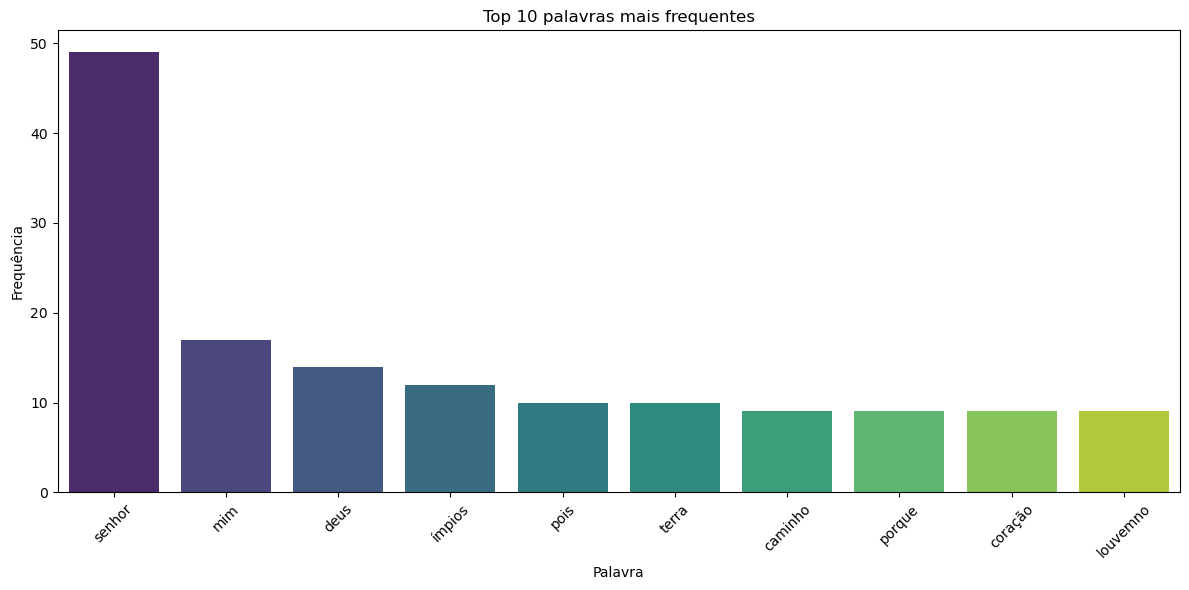

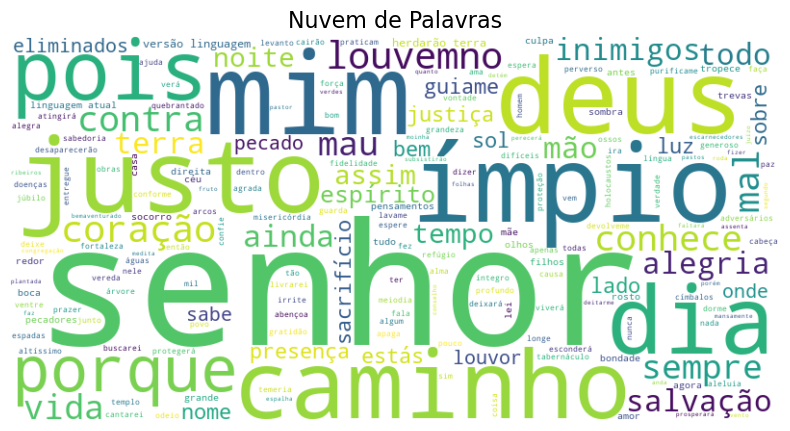

In [3]:
df_salmos = analisar_salmos_docx("Salmos_Para_Analise")

## Análise de Sentimentos dos Salmos

A análise de sentimentos é uma técnica do Processamento de Linguagem Natural (NLP) utilizada para identificar e categorizar emoções expressas em um texto, como positividade, negatividade ou neutralidade. No contexto dos Salmos — textos de caráter profundamente emocional e espiritual — essa abordagem é especialmente relevante, pois permite explorar como sentimentos como fé, esperança, medo, arrependimento, alegria e gratidão são expressos por meio da linguagem.

## Como funciona:

A análise de sentimento se baseia na polaridade do texto. Essa polaridade é uma medida numérica que reflete o grau de positividade ou negatividade do conteúdo. O valor da polaridade geralmente varia entre -1 e +1:

- Polaridade positiva (acima de 0): Significa que o texto tem um sentimento positivo. Quanto mais próximo de +1, mais forte e positivo é o sentimento. Exemplos: felicidade, alegria, gratidão.

- Polaridade negativa (abaixo de 0): Significa que o texto tem um sentimento negativo. Quanto mais próximo de -1, mais forte e negativo é o sentimento. Exemplos: raiva, tristeza, frustração.

- Polaridade neutra (próxima de 0): Significa que o texto não expressa um sentimento claro ou forte, sendo considerado neutro. Exemplos: fatos, descrições objetivas, ou texto sem emoção destacada.

In [4]:
!pip install vaderSentiment

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Versão adaptada com stopwords em português
analisador = SentimentIntensityAnalyzer()

# Ajuste básico para português
# (Adicionamos palavras mais comuns ou religiosas se quiser depois)
analisador.lexicon.update({
    "amor": 2.0,
    "paz": 1.5,
    "graça": 1.8,
    "alegria": 2.2,
    "misericórdia": 1.7,
    "justiça": 1.4,
    "ódio": -2.5,
    "pecado": -1.9,
    "culpa": -2.0,
    "perdão": 1.8,
})

# 🧠 Função para analisar sentimento de um texto
def analisar_sentimento(texto):
    scores = analisador.polarity_scores(texto)
    return scores["compound"]  # valor entre -1 (negativo) e +1 (positivo)

In [6]:
texto = ler_docx("Salmos_Para_Analise")
salmos = extrair_salmos(texto)

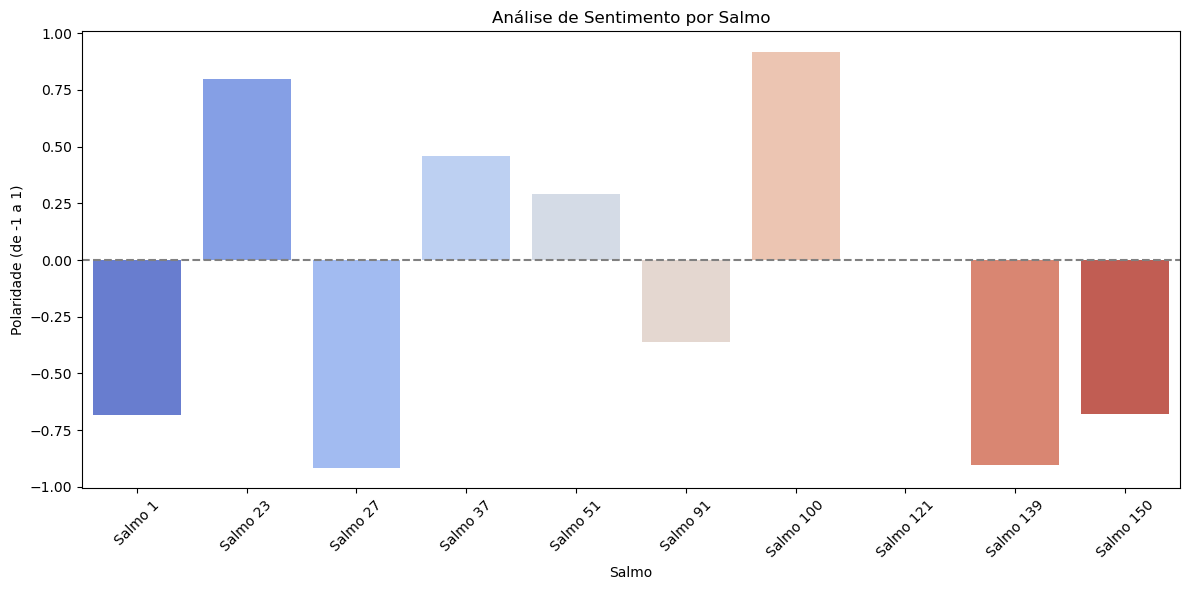

Salmo Salmo 1: Sentimento Negativo (Polaridade: -0.6808)
Salmo Salmo 23: Sentimento Positivo (Polaridade: 0.7964)
Salmo Salmo 27: Sentimento Negativo (Polaridade: -0.9146)
Salmo Salmo 37: Sentimento Positivo (Polaridade: 0.4588)
Salmo Salmo 51: Sentimento Positivo (Polaridade: 0.2933)
Salmo Salmo 91: Sentimento Negativo (Polaridade: -0.3595)
Salmo Salmo 100: Sentimento Positivo (Polaridade: 0.9168)
Salmo Salmo 121: Sentimento Neutro (Polaridade: 0.0)
Salmo Salmo 139: Sentimento Negativo (Polaridade: -0.9048)
Salmo Salmo 150: Sentimento Negativo (Polaridade: -0.6776)


In [7]:
# 🔎 Análise de sentimento por salmo
sentimentos = []

for nome, conteudo in salmos.items():
    # Obter polaridade do sentimento
    sentimento = analisar_sentimento(conteudo)
    
    # Determinar se o sentimento é positivo ou negativo
    if sentimento > 0:
        sentimento_texto = "Positivo"
    elif sentimento < 0:
        sentimento_texto = "Negativo"
    else:
        sentimento_texto = "Neutro"
    
    # Adicionar análise ao dataframe
    sentimentos.append({"Salmo": nome, "Sentimento (Polaridade)": sentimento, "Classificação": sentimento_texto})

df_sentimentos = pd.DataFrame(sentimentos)

# 📈 Visualizar sentimento
plt.figure(figsize=(12, 6))
sns.barplot(data=df_sentimentos, x="Salmo", y="Sentimento (Polaridade)", palette="coolwarm")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Análise de Sentimento por Salmo")
plt.ylabel("Polaridade (de -1 a 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Exibir resultados como texto
for index, row in df_sentimentos.iterrows():
    print(f"Salmo {row['Salmo']}: Sentimento {row['Classificação']} (Polaridade: {row['Sentimento (Polaridade)']})")

## Analisando o resultado

Esse resultado de análise de sentimentos, à primeira vista, parece contradizer a experiência subjetiva que muitos leitores têm ao ler os Salmos. Salmos como o 23, o 100 ou o 150 são universalmente reconhecidos como expressões de louvor, confiança e alegria — ainda assim, vemos alguns deles classificados como “**negativos**”. Vamos analisar **por que isso acontece**:

---

## Por que alguns Salmos foram classificados como "Negativos"?

### 1. **Limitações das ferramentas de análise de sentimentos**

A maioria das bibliotecas de análise de sentimentos em inglês (como VADER, TextBlob ou até transformers mais modernos) **foi treinada em textos contemporâneos** — como tweets, avaliações de produtos ou artigos jornalísticos. Isso faz com que essas ferramentas:

* **Interpretem mal construções bíblicas**, que usam arcaísmos, metáforas e estruturas pouco comuns.
* **Atribuam sentimentos negativos a palavras isoladas** como *inimigo*, *mal*, *medo*, *escuridão*, *julgamento*, mesmo quando estão inseridas em um contexto de superação ou proteção divina.

### 2. **Presença de palavras negativas em contextos positivos**

Mesmo em salmos que expressam fé e confiança, como o **Salmo 91**, há menções a:

> “terror da noite”, “peste”, “espada”, “mil cairão ao teu lado”.

Ferramentas de sentimento analisam o texto **linha a linha** ou **em blocos**, sem a capacidade de compreender **a intenção teológica** por trás das palavras. Assim, a simples presença dessas palavras é interpretada como "negatividade".

### 3. **Contrastes emocionais dentro de um mesmo salmo**

Alguns salmos expressam contraste entre medo e fé. O **Salmo 27**, por exemplo, começa afirmando:

> “O Senhor é a minha luz e a minha salvação; de quem terei medo?”

Mas também menciona:

> “Quando malfeitores me sobrevêm para me destruir...”

Esses contrastes são difíceis de interpretar com precisão por algoritmos que não têm senso teológico nem contextual.

### 4. **Polaridade média desbalanceada**

A polaridade é uma média. Se um salmo traz muitas palavras emocionalmente carregadas (positivas e negativas), a média pode acabar pendendo para o negativo mesmo que o tom geral do texto soe esperançoso ou devocional.


## E o caso do Salmo 51?

O Salmo 51 é um exemplo clássico de **arrependimento profundo**. E mesmo assim, ele aparece como positivo. Isso ocorre porque palavras como *misericórdia*, *Purifica-me*, *alegria*, *renovação*, *salvação*, etc., estão ligadas a uma **esperança na restauração** — mesmo diante do pecado. Esse tipo de emoção é capturado como "positivo" pela maioria dos modelos.


## Conclusão

Os resultados são **tecnicamente coerentes**, mas **não capturam a intenção espiritual ou poética dos textos bíblicos**. Para uma análise mais fiel:

* Seria interessante **treinar um modelo específico** com textos religiosos.
* Ou ainda **fazer análise de sentimento por blocos contextuais**, e não por palavras ou frases isoladas.

Se quiser, posso te ajudar a aplicar uma abordagem mais precisa — por exemplo, com **classificadores ajustados ou análise baseada em emoção (raiva, medo, alegria, esperança, etc.)**. Quer seguir por esse caminho?


## Análise de Sentimentos com Salmos em Inglês

Para verificar se a língua do texto influencia os resultados da análise de sentimentos, realizarei agora a mesma análise utilizando os Salmos em sua versão original em **inglês**. O objetivo é observar se a polaridade e a classificação emocional se alteram quando aplicamos o modelo diretamente no idioma para o qual ele foi treinado, evitando possíveis distorções causadas pela tradução automática.

In [8]:
from deep_translator import GoogleTranslator

In [9]:
# Baixar stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))  # Mudado para inglês

# 📥 Função para ler arquivos .docx
def ler_docx(caminho):
    doc = Document(caminho + ".docx")  # <-- usa .docx aqui
    texto = ""
    for p in doc.paragraphs:
        if p.text.strip():
            texto += p.text + "\n"
    return texto

# ✂️ Função para dividir salmos por título
def extrair_salmos(texto):
    salmos = re.split(r'\bPsalm?\s+(\d+)', texto, flags=re.IGNORECASE)
    salmos_extraidos = {}
    for i in range(1, len(salmos), 2):
        numero = salmos[i].strip()
        conteudo = salmos[i+1].strip()
        salmos_extraidos[f"Psalm {numero}"] = conteudo  # Mudado para inglês
    return salmos_extraidos

# 🧼 Função para processar o texto e remover stopwords e pontuação
def preprocessar_texto(texto):
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    palavras = texto.split()
    palavras_filtradas = [p for p in palavras if p not in stop_words and len(p) > 2]
    return palavras_filtradas

# 🧠 Função principal para análise
def analisar_salmos_docx(caminho_arquivo):
    texto = ler_docx(caminho_arquivo)
    salmos = extrair_salmos(texto)
    todas_palavras = []
    dados = []

    for nome, conteudo in salmos.items():
        palavras = preprocessar_texto(conteudo)
        contagem = Counter(palavras)
        for palavra, freq in contagem.items():
            dados.append({"Psalm": nome, "Word": palavra, "Frequency": freq})  # Mudado para inglês
        todas_palavras.extend(palavras)

    df = pd.DataFrame(dados)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alanf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Inicializando o analisador de sentimentos
analisador = SentimentIntensityAnalyzer()

# Atualizar o léxico do analisador com palavras mais comuns ou religiosas, se necessário
analisador.lexicon.update({
    "love": 2.0,
    "peace": 1.5,
    "grace": 1.8,
    "joy": 2.2,
    "mercy": 1.7,
    "justice": 1.4,
    "hate": -2.5,
    "sin": -1.9,
    "guilt": -2.0,
    "forgiveness": 1.8,
})

In [11]:
# Função para analisar o sentimento de um texto
def analisar_sentimento(texto):
    scores = analisador.polarity_scores(texto)
    return scores["compound"]  # Retorna a polaridade entre -1 (negativo) e +1 (positivo)

In [14]:
# Função para ler o arquivo DOCX (já foi adaptada no código anterior)
def ler_docx(caminho):
    doc = Document(caminho + ".docx")
    texto = ""
    for p in doc.paragraphs:
        if p.text.strip():
            texto += p.text + "\n"
    return texto

# Função para extrair os Salmos (você pode ajustar isso conforme necessário)
def extrair_salmos(texto):
    salmos = {}
    linhas = texto.split("\n")
    salmo_atual = None
    conteudo_atual = []

    for linha in linhas:
        if linha.strip().startswith("Psalm"):
            if salmo_atual:
                salmos[salmo_atual] = " ".join(conteudo_atual)
            salmo_atual = linha.strip()
            conteudo_atual = []
        else:
            conteudo_atual.append(linha.strip())

    if salmo_atual:
        salmos[salmo_atual] = " ".join(conteudo_atual)

    return salmos

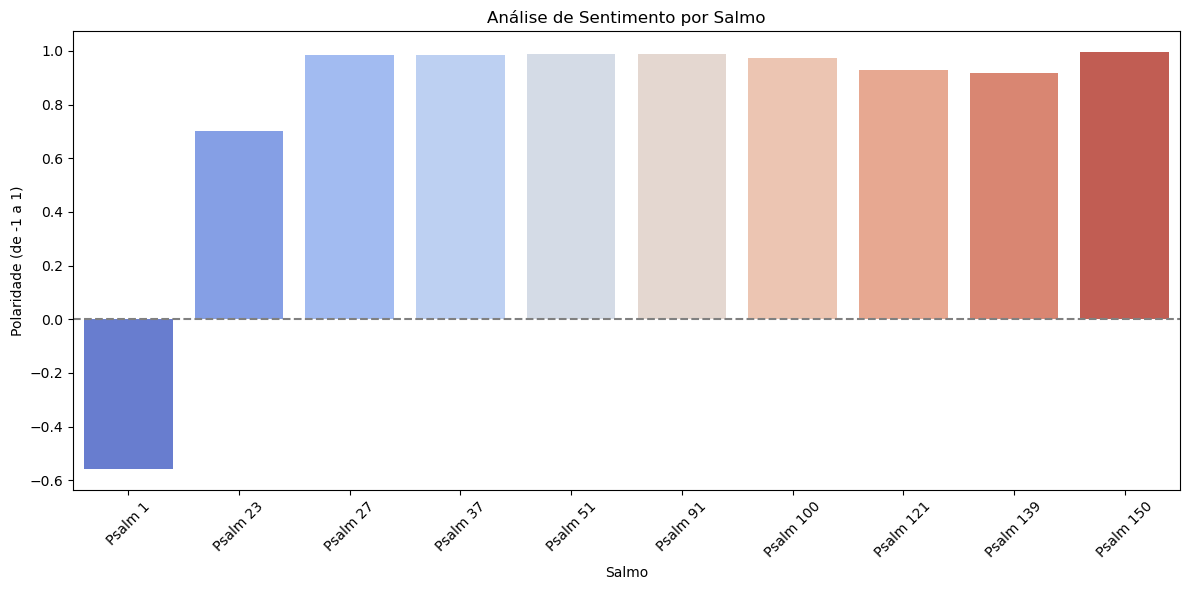

In [16]:
# Texto extraído do arquivo DOCX
texto = ler_docx("Salmos_Para_Analise_INGLES")

# Extrair os salmos do texto
salmos = extrair_salmos(texto)

# Análise de sentimento por Salmo
sentimentos = []

for nome, conteudo in salmos.items():
    # Obter polaridade do sentimento
    sentimento = analisar_sentimento(conteudo)
    
    # Determinar se o sentimento é positivo, negativo ou neutro
    if sentimento > 0:
        sentimento_texto = "Positivo"
    elif sentimento < 0:
        sentimento_texto = "Negativo"
    else:
        sentimento_texto = "Neutro"
    
    # Adicionar análise ao dataframe
    sentimentos.append({"Salmo": nome, "Sentimento (Polaridade)": sentimento, "Classificação": sentimento_texto})

# Criar DataFrame com os resultados
df_sentimentos = pd.DataFrame(sentimentos)

# Visualizar sentimentos por Salmo
plt.figure(figsize=(12, 6))
sns.barplot(data=df_sentimentos, x="Salmo", y="Sentimento (Polaridade)", palette="coolwarm")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Análise de Sentimento por Salmo")
plt.ylabel("Polaridade (de -1 a 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analisando o resultado

Esse novo resultado da análise de sentimentos utilizando os **Salmos em inglês** mostra uma diferença significativa em relação à versão anterior feita com os textos traduzidos para o português.

### Observações principais:

* **9 dos 10 Salmos** foram classificados com **sentimento positivo**.
* Apenas o **Salmo 1** foi identificado com **sentimento negativo**, o que pode estar relacionado ao contraste entre os justos e os ímpios presente nesse salmo, algo que o algoritmo pode interpretar como negatividade devido ao uso de palavras como *wicked*, *perish*, *sinners* etc.

### Interpretação:

Esses resultados fazem mais sentido do ponto de vista **teológico e literário**. Os Salmos analisados são, em sua maioria, orações de louvor, confiança, arrependimento sincero ou adoração — mensagens que carregam mais carga emocional positiva. O modelo de análise de sentimentos usado (baseado em regras como o `TextBlob`, por exemplo) foi treinado com textos **em inglês**, o que explica por que os resultados nesta versão do idioma são mais coerentes com uma leitura humana.

### Conclusão:

A análise feita diretamente em **inglês** mostra-se **mais confiável** e **consistente** com o conteúdo emocional dos Salmos. Isso reforça a importância de aplicar modelos de NLP (Processamento de Linguagem Natural) no idioma original ou, ao menos, em versões que mantenham a fidelidade semântica, para evitar distorções causadas por traduções automáticas.